In [1]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
BASE_DIR = Path.cwd()

DATASET_DIR = BASE_DIR / "dataset"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATASET_DIR / "train10.csv"

print("Base directory:", BASE_DIR)
print("Dataset path:", TRAIN_PATH)
print("File exists:", TRAIN_PATH.exists())

Base directory: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3
Dataset path: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\dataset\train10.csv
File exists: True


In [3]:
df = pd.read_csv(TRAIN_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (128445, 1160)


,Unnamed: 0,depmap_id,drugname1,drugname2,drug1,drug2,cancer,cell line,score,seneitive10,...,RNAi_Gastric cancer - Homo sapiens (human),RNAi_Central carbon metabolism in cancer - Homo sapiens (human),RNAi_Choline metabolism in cancer - Homo sapiens (human),RNAi_PD-L1 expression and PD-1 checkpoint pathway in cancer - Homo sapiens (human),RNAi_Inflammatory bowel disease - Homo sapiens (human),RNAi_Rheumatoid arthritis - Homo sapiens (human),RNAi_Diabetic cardiomyopathy - Homo sapiens (human),RNAi_Viral myocarditis - Homo sapiens (human),RNAi_Lipid and atherosclerosis - Homo sapiens (human),RNAi_Fluid shear stress and atherosclerosis - Homo sapiens (human)
0,1,ACH-000001,Methotrexate,Romidepsin,740,754143,Ovarian Cancer,OVCAR-3,-10.444444,0,...,0.003639,-0.090998,-0.126698,0.027054,0.026742,0.021201,-0.132627,0.188628,0.075965,0.192769
1,2,ACH-000001,Temozolomide,Ruxolitinib,362856,763371,Ovarian Cancer,OVCAR-3,-4.555556,0,...,0.003639,-0.090998,-0.126698,0.027054,0.026742,0.021201,-0.132627,0.188628,0.075965,0.192769
2,3,ACH-000001,Everolimus,Sunitinib,733504,750690,Ovarian Cancer,OVCAR-3,-9.666667,0,...,0.003639,-0.090998,-0.126698,0.027054,0.026742,0.021201,-0.132627,0.188628,0.075965,0.192769
3,4,ACH-000001,Carmustine,Vismodegib,409962,755986,Ovarian Cancer,OVCAR-3,-3.555556,0,...,0.003639,-0.090998,-0.126698,0.027054,0.026742,0.021201,-0.132627,0.188628,0.075965,0.192769
4,5,ACH-000001,Oxaliplatin,Sunitinib,266046,750690,Ovarian Cancer,OVCAR-3,-15.888889,0,...,0.003639,-0.090998,-0.126698,0.027054,0.026742,0.021201,-0.132627,0.188628,0.075965,0.192769


In [4]:
print("Columns:")
for col in df.columns:
    print(col)

Columns:
Unnamed: 0
depmap_id
drugname1
drugname2
drug1
drug2
cancer
cell line
score
seneitive10
cut4
drug_combination
DD_maccs_maccs37
DD_maccs_maccs38
DD_maccs_maccs42
DD_maccs_maccs50
DD_maccs_maccs52
DD_maccs_maccs53
DD_maccs_maccs54
DD_maccs_maccs55
DD_maccs_maccs57
DD_maccs_maccs58
DD_maccs_maccs60
DD_maccs_maccs61
DD_maccs_maccs62
DD_maccs_maccs65
DD_maccs_maccs66
DD_maccs_maccs67
DD_maccs_maccs69
DD_maccs_maccs72
DD_maccs_maccs73
DD_maccs_maccs74
DD_maccs_maccs75
DD_maccs_maccs76
DD_maccs_maccs77
DD_maccs_maccs79
DD_maccs_maccs80
DD_maccs_maccs81
DD_maccs_maccs82
DD_maccs_maccs83
DD_maccs_maccs84
DD_maccs_maccs85
DD_maccs_maccs86
DD_maccs_maccs87
DD_maccs_maccs88
DD_maccs_maccs89
DD_maccs_maccs90
DD_maccs_maccs91
DD_maccs_maccs92
DD_maccs_maccs93
DD_maccs_maccs94
DD_maccs_maccs95
DD_maccs_maccs96
DD_maccs_maccs97
DD_maccs_maccs98
DD_maccs_maccs99
DD_maccs_maccs100
DD_maccs_maccs101
DD_maccs_maccs102
DD_maccs_maccs103
DD_maccs_maccs104
DD_maccs_maccs105
DD_maccs_maccs106
DD_macc

In [5]:
possible_target_cols = [
    "ComboScore", "COMBOSCORE", "comboscore",
    "combo_score", "Combo_Score",
    "score", "target", "y"
]

target_col = None

for col in possible_target_cols:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError(
        f"Target column not found. Available columns are:\n{list(df.columns)}"
    )

print("Detected target column:", target_col)

Detected target column: score


In [6]:
before_rows = len(df)

df = df.dropna(subset=[target_col]).copy()

after_rows = len(df)

print("Rows before removing missing target:", before_rows)
print("Rows after removing missing target:", after_rows)
print("Removed rows:", before_rows - after_rows)

Rows before removing missing target: 128445
Rows after removing missing target: 128445
Removed rows: 0


In [7]:
drop_cols = [
    target_col,
    "Unnamed: 0",
    "index",
    "ID",
    "id"
]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target_col].astype(float)

print("X shape before preprocessing:", X.shape)
print("y shape:", y.shape)

X shape before preprocessing: (128445, 1158)
y shape: (128445,)


In [8]:
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

print("\nFirst 20 numeric columns:")
print(numeric_cols[:20])

print("\nCategorical columns:")
print(categorical_cols)

Number of numeric columns: 1152
Number of categorical columns: 6

First 20 numeric columns:
['drug1', 'drug2', 'seneitive10', 'cut4', 'DD_maccs_maccs37', 'DD_maccs_maccs38', 'DD_maccs_maccs42', 'DD_maccs_maccs50', 'DD_maccs_maccs52', 'DD_maccs_maccs53', 'DD_maccs_maccs54', 'DD_maccs_maccs55', 'DD_maccs_maccs57', 'DD_maccs_maccs58', 'DD_maccs_maccs60', 'DD_maccs_maccs61', 'DD_maccs_maccs62', 'DD_maccs_maccs65', 'DD_maccs_maccs66', 'DD_maccs_maccs67']

Categorical columns:
['depmap_id', 'drugname1', 'drugname2', 'cancer', 'cell line', 'drug_combination']


In [9]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (102756, 1158)
X_test: (25689, 1158)
y_train: (102756,)
y_test: (25689,)


In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [11]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (102756, 4893)
X_test_processed shape: (25689, 4893)


In [12]:
preprocessor_path = MODELS_DIR / "advanced_models_preprocessor.pkl"

joblib.dump(preprocessor, preprocessor_path)

print("Preprocessor saved at:", preprocessor_path)

Preprocessor saved at: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\models\advanced_models_preprocessor.pkl


In [13]:
processed_data_path = RESULTS_DIR / "advanced_models_processed_train_test_data.pkl"

processed_data = {
    "X_train_processed": X_train_processed,
    "X_test_processed": X_test_processed,
    "y_train": y_train.values,
    "y_test": y_test.values,
    "X_train_original": X_train,
    "X_test_original": X_test,
    "target_col": target_col,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE
}

joblib.dump(processed_data, processed_data_path)

print("Processed data saved at:", processed_data_path)

Processed data saved at: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\advanced_models_processed_train_test_data.pkl


In [14]:
print("Final verification")
print("-" * 50)
print("Original dataset shape:", df.shape)
print("Target column:", target_col)
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Any NaN in X_train_processed:", np.isnan(X_train_processed).any())
print("Any NaN in X_test_processed:", np.isnan(X_test_processed).any())
print("Any NaN in y_train:", np.isnan(y_train.values).any())
print("Any NaN in y_test:", np.isnan(y_test.values).any())

Final verification
--------------------------------------------------
Original dataset shape: (128445, 1160)
Target column: score
Numeric columns: 1152
Categorical columns: 6
Processed train shape: (102756, 4893)
Processed test shape: (25689, 4893)
Any NaN in X_train_processed: False
Any NaN in X_test_processed: False
Any NaN in y_train: False
Any NaN in y_test: False


In [15]:
from ngboost import NGBRegressor
import pyswarms as ps

print("NGBoost and PySwarms loaded successfully")

NGBoost and PySwarms loaded successfully


In [16]:
from ngboost import NGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

ngb = NGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    random_state=RANDOM_STATE,
    verbose=False
)

ngb.fit(X_train_processed, y_train)

ngb_pred = ngb.predict(X_test_processed)

ngb_r2 = r2_score(y_test, ngb_pred)
ngb_mae = mean_absolute_error(y_test, ngb_pred)
ngb_rmse = np.sqrt(mean_squared_error(y_test, ngb_pred))

print("NGBoost Results")
print("R2:", ngb_r2)
print("MAE:", ngb_mae)
print("RMSE:", ngb_rmse)

NGBoost Results
R2: 0.4804813624711374
MAE: 3.4248852136235057
RMSE: 4.952710538006435


In [17]:
ngboost_model_path = MODELS_DIR / "ngboost_model.pkl"
joblib.dump(ngb, ngboost_model_path)

print("NGBoost model saved at:", ngboost_model_path)

NGBoost model saved at: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\models\ngboost_model.pkl


In [18]:
ngboost_predictions = pd.DataFrame({
    "Actual_ComboScore": y_test.values,
    "Predicted_ComboScore": ngb_pred
})

ngboost_pred_path = RESULTS_DIR / "ngboost_predictions.csv"
ngboost_predictions.to_csv(ngboost_pred_path, index=False)

print("NGBoost predictions saved at:", ngboost_pred_path)

NGBoost predictions saved at: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\ngboost_predictions.csv


In [19]:
import time
import numpy as np
import pandas as pd
import joblib

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from scipy.stats import pearsonr, spearmanr
from scipy import sparse

from pyswarms.single.global_best import GlobalBestPSO

print("PSO-SVR libraries imported successfully")

PSO-SVR libraries imported successfully


In [20]:
y_train_array = np.asarray(y_train).ravel()
y_test_array = np.asarray(y_test).ravel()

print("y_train_array shape:", y_train_array.shape)
print("y_test_array shape:", y_test_array.shape)

y_train_array shape: (102756,)
y_test_array shape: (25689,)


In [21]:
def sample_data(X, y, max_rows=2000, random_state=42):
    """
    Samples rows for faster PSO-SVR tuning.
    Works with numpy arrays and sparse matrices.
    """
    n_rows = X.shape[0]
    
    if max_rows is None or n_rows <= max_rows:
        return X, y
    
    rng = np.random.default_rng(random_state)
    idx = rng.choice(n_rows, size=max_rows, replace=False)
    
    return X[idx], y[idx]


def evaluate_regression(y_true, y_pred):
    """
    Calculates regression metrics.
    """
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    try:
        pearson_corr = pearsonr(y_true, y_pred)[0]
    except Exception:
        pearson_corr = np.nan
        
    try:
        spearman_corr = spearmanr(y_true, y_pred)[0]
    except Exception:
        spearman_corr = np.nan
    
    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Pearson": pearson_corr,
        "Spearman": spearman_corr
    }


print("Helper functions ready")

Helper functions ready


In [22]:
PSO_TUNE_MAX_ROWS = 1500   # increase to 3000 later if your laptop handles it

X_pso_base, y_pso_base = sample_data(
    X_train_processed,
    y_train_array,
    max_rows=PSO_TUNE_MAX_ROWS,
    random_state=RANDOM_STATE
)

X_pso_train, X_pso_val, y_pso_train, y_pso_val = train_test_split(
    X_pso_base,
    y_pso_base,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("PSO train shape:", X_pso_train.shape)
print("PSO validation shape:", X_pso_val.shape)

PSO train shape: (1125, 4893)
PSO validation shape: (375, 4893)


In [23]:
def pso_svr_objective(particles):
    """
    Objective function for PSO.
    
    Each particle contains:
    particle[0] = log10(C)
    particle[1] = log10(gamma)
    particle[2] = log10(epsilon)
    
    PSO minimizes validation RMSE.
    """
    scores = []
    
    for particle in particles:
        log_C, log_gamma, log_epsilon = particle
        
        C = 10 ** log_C
        gamma = 10 ** log_gamma
        epsilon = 10 ** log_epsilon
        
        try:
            model = SVR(
                kernel="rbf",
                C=C,
                gamma=gamma,
                epsilon=epsilon,
                cache_size=1000
            )
            
            model.fit(X_pso_train, y_pso_train)
            val_pred = model.predict(X_pso_val)
            
            rmse = np.sqrt(mean_squared_error(y_pso_val, val_pred))
            scores.append(rmse)
            
        except Exception as e:
            scores.append(1e10)
    
    return np.array(scores)


print("PSO-SVR objective function ready")

PSO-SVR objective function ready


In [24]:
# Search space:
# C:       10^-2 to 10^3   = 0.01 to 1000
# gamma:   10^-5 to 10^-1 = 0.00001 to 0.1
# epsilon: 10^-3 to 10^1  = 0.001 to 10

lower_bounds = np.array([-2, -5, -3])
upper_bounds = np.array([3, -1, 1])
bounds = (lower_bounds, upper_bounds)

options = {
    "c1": 0.5,
    "c2": 0.3,
    "w": 0.9
}

N_PARTICLES = 8
N_ITERATIONS = 10

optimizer = GlobalBestPSO(
    n_particles=N_PARTICLES,
    dimensions=3,
    options=options,
    bounds=bounds
)

start_time = time.time()

best_cost, best_position = optimizer.optimize(
    pso_svr_objective,
    iters=N_ITERATIONS
)

pso_time = time.time() - start_time

best_log_C, best_log_gamma, best_log_epsilon = best_position

best_C = 10 ** best_log_C
best_gamma = 10 ** best_log_gamma
best_epsilon = 10 ** best_log_epsilon

print("\nBest PSO-SVR Parameters")
print("-" * 40)
print("Best validation RMSE:", best_cost)
print("Best C:", best_C)
print("Best gamma:", best_gamma)
print("Best epsilon:", best_epsilon)
print("PSO optimization time:", round(pso_time, 2), "seconds")

2026-05-06 20:50:47,800 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|10/10, best_cost=5.62
2026-05-06 20:57:06,082 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 5.622078976725951, best pos: [ 1.95674259 -3.535831   -0.16940272]



Best PSO-SVR Parameters
----------------------------------------
Best validation RMSE: 5.622078976725951
Best C: 90.5195921257829
Best gamma: 0.000291184999803216
Best epsilon: 0.6770134180378176
PSO optimization time: 378.28 seconds


In [25]:
FINAL_SVR_MAX_ROWS = 5000   # change to None only if your system can handle full training

X_svr_final_train, y_svr_final_train = sample_data(
    X_train_processed,
    y_train_array,
    max_rows=FINAL_SVR_MAX_ROWS,
    random_state=RANDOM_STATE
)

print("Final SVR training shape:", X_svr_final_train.shape)

pso_svr_model = SVR(
    kernel="rbf",
    C=best_C,
    gamma=best_gamma,
    epsilon=best_epsilon,
    cache_size=1000
)

start_time = time.time()

pso_svr_model.fit(X_svr_final_train, y_svr_final_train)

pso_svr_train_time = time.time() - start_time

print("Final PSO-SVR trained successfully")
print("Training time:", round(pso_svr_train_time, 2), "seconds")

Final SVR training shape: (5000, 4893)
Final PSO-SVR trained successfully
Training time: 75.96 seconds


In [26]:
pso_svr_pred = pso_svr_model.predict(X_test_processed)

pso_svr_metrics = evaluate_regression(y_test_array, pso_svr_pred)

print("PSO-SVR Results")
print("-" * 40)
for metric, value in pso_svr_metrics.items():
    print(metric, ":", value)

PSO-SVR Results
----------------------------------------
R2 : 0.34544270139087707
MAE : 3.6358373923010925
RMSE : 5.559250131991424
Pearson : 0.5943951368848455
Spearman : 0.46757645071757203


In [27]:
pso_svr_bundle = {
    "model": pso_svr_model,
    "best_params": {
        "C": best_C,
        "gamma": best_gamma,
        "epsilon": best_epsilon
    },
    "pso_settings": {
        "n_particles": N_PARTICLES,
        "n_iterations": N_ITERATIONS,
        "pso_tune_max_rows": PSO_TUNE_MAX_ROWS,
        "final_svr_max_rows": FINAL_SVR_MAX_ROWS,
        "best_validation_rmse": best_cost
    }
}

pso_svr_model_path = MODELS_DIR / "pso_svr_model.pkl"

joblib.dump(pso_svr_bundle, pso_svr_model_path)

print("PSO-SVR model saved at:", pso_svr_model_path)

PSO-SVR model saved at: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\models\pso_svr_model.pkl


In [28]:
pso_svr_predictions = pd.DataFrame({
    "Actual_ComboScore": y_test_array,
    "Predicted_ComboScore": pso_svr_pred
})

pso_svr_pred_path = RESULTS_DIR / "pso_svr_predictions.csv"

pso_svr_predictions.to_csv(pso_svr_pred_path, index=False)

print("PSO-SVR predictions saved at:", pso_svr_pred_path)

PSO-SVR predictions saved at: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\pso_svr_predictions.csv


In [29]:
ngboost_metrics = evaluate_regression(y_test_array, ngb_pred)

advanced_model_comparison = pd.DataFrame([
    {
        "Model": "NGBoost",
        "R2": ngboost_metrics["R2"],
        "MAE": ngboost_metrics["MAE"],
        "RMSE": ngboost_metrics["RMSE"],
        "Pearson": ngboost_metrics["Pearson"],
        "Spearman": ngboost_metrics["Spearman"]
    },
    {
        "Model": "PSO-SVR",
        "R2": pso_svr_metrics["R2"],
        "MAE": pso_svr_metrics["MAE"],
        "RMSE": pso_svr_metrics["RMSE"],
        "Pearson": pso_svr_metrics["Pearson"],
        "Spearman": pso_svr_metrics["Spearman"]
    }
])

comparison_path = RESULTS_DIR / "advanced_model_comparison.csv"

advanced_model_comparison.to_csv(comparison_path, index=False)

display(advanced_model_comparison)

print("Advanced model comparison saved at:", comparison_path)

,Model,R2,MAE,RMSE,Pearson,Spearman
0,NGBoost,0.480481,3.424885,4.952711,0.698010,0.474109
1,PSO-SVR,0.345443,3.635837,5.559250,0.594395,0.467576


Advanced model comparison saved at: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\advanced_model_comparison.csv


In [30]:
combined_advanced_predictions = pd.DataFrame({
    "Actual_ComboScore": y_test_array,
    "NGBoost_Prediction": ngb_pred,
    "PSO_SVR_Prediction": pso_svr_pred
})

combined_pred_path = RESULTS_DIR / "ngboost_pso_svr_combined_predictions.csv"

combined_advanced_predictions.to_csv(combined_pred_path, index=False)

print("Combined predictions saved at:", combined_pred_path)

Combined predictions saved at: c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\ngboost_pso_svr_combined_predictions.csv


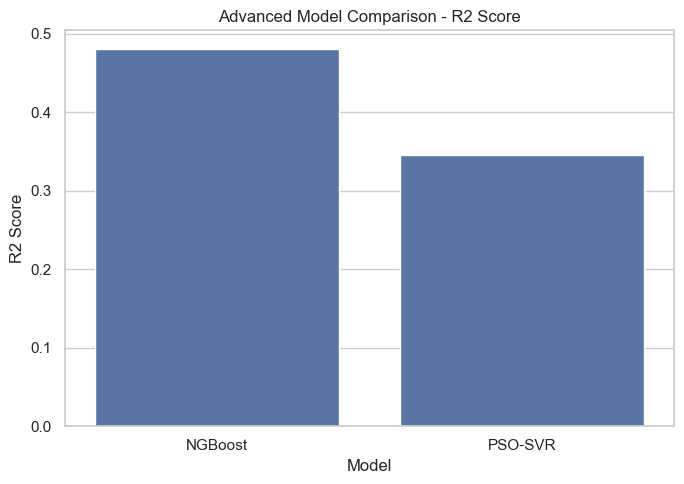

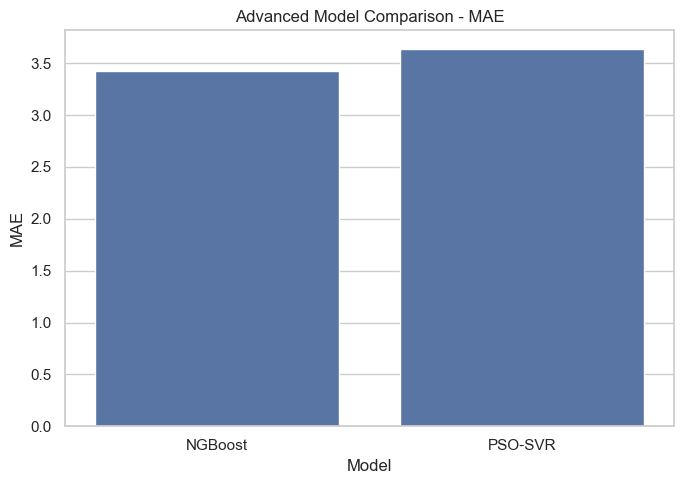

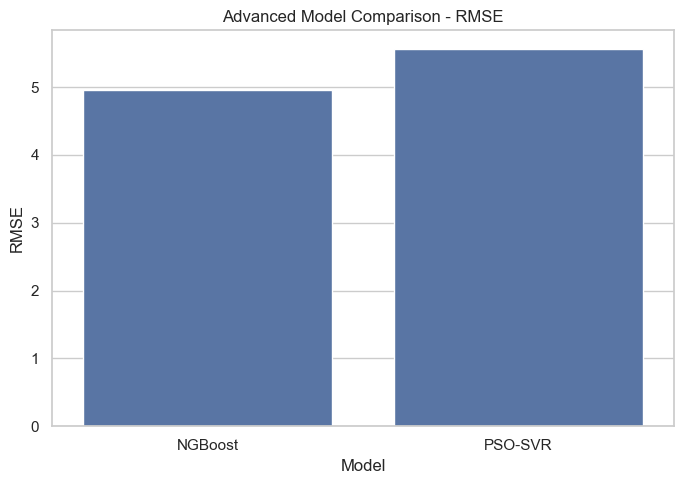

Charts saved:
c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\advanced_models_r2_comparison.png
c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\advanced_models_mae_comparison.png
c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\advanced_models_rmse_comparison.png


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plot_df = advanced_model_comparison.copy()

# R2 chart
plt.figure(figsize=(7, 5))
sns.barplot(data=plot_df, x="Model", y="R2")
plt.title("Advanced Model Comparison - R2 Score")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.tight_layout()
r2_plot_path = RESULTS_DIR / "advanced_models_r2_comparison.png"
plt.savefig(r2_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# MAE chart
plt.figure(figsize=(7, 5))
sns.barplot(data=plot_df, x="Model", y="MAE")
plt.title("Advanced Model Comparison - MAE")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.tight_layout()
mae_plot_path = RESULTS_DIR / "advanced_models_mae_comparison.png"
plt.savefig(mae_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# RMSE chart
plt.figure(figsize=(7, 5))
sns.barplot(data=plot_df, x="Model", y="RMSE")
plt.title("Advanced Model Comparison - RMSE")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.tight_layout()
rmse_plot_path = RESULTS_DIR / "advanced_models_rmse_comparison.png"
plt.savefig(rmse_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Charts saved:")
print(r2_plot_path)
print(mae_plot_path)
print(rmse_plot_path)

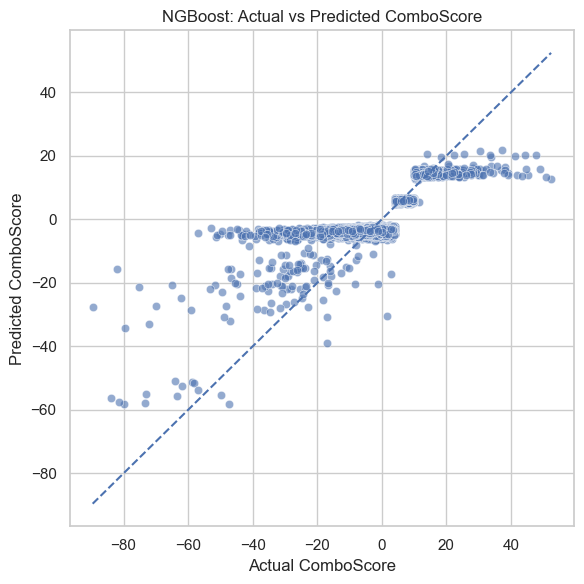

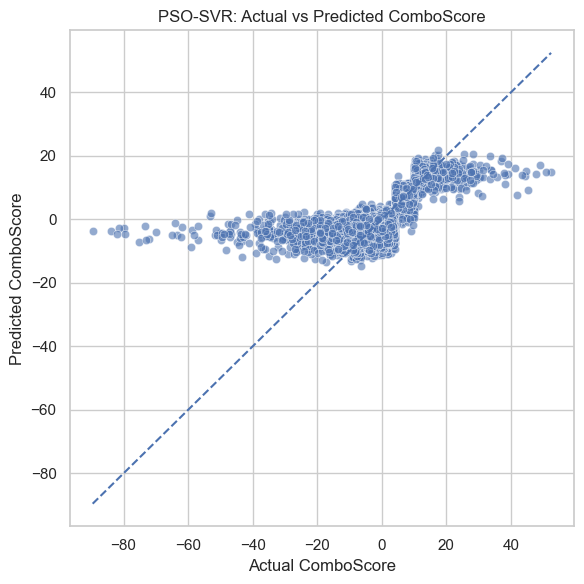

Scatter plots saved:
c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\ngboost_actual_vs_predicted.png
c:\Users\HP\Desktop\SDP 27 april\nci_almanac_v3\results\pso_svr_actual_vs_predicted.png


In [32]:
# NGBoost actual vs predicted
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_array, y=ngb_pred, alpha=0.6)
plt.plot(
    [y_test_array.min(), y_test_array.max()],
    [y_test_array.min(), y_test_array.max()],
    linestyle="--"
)
plt.title("NGBoost: Actual vs Predicted ComboScore")
plt.xlabel("Actual ComboScore")
plt.ylabel("Predicted ComboScore")
plt.tight_layout()
ngb_scatter_path = RESULTS_DIR / "ngboost_actual_vs_predicted.png"
plt.savefig(ngb_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

# PSO-SVR actual vs predicted
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_array, y=pso_svr_pred, alpha=0.6)
plt.plot(
    [y_test_array.min(), y_test_array.max()],
    [y_test_array.min(), y_test_array.max()],
    linestyle="--"
)
plt.title("PSO-SVR: Actual vs Predicted ComboScore")
plt.xlabel("Actual ComboScore")
plt.ylabel("Predicted ComboScore")
plt.tight_layout()
pso_svr_scatter_path = RESULTS_DIR / "pso_svr_actual_vs_predicted.png"
plt.savefig(pso_svr_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print("Scatter plots saved:")
print(ngb_scatter_path)
print(pso_svr_scatter_path)

In [33]:
print("Final Advanced Model Verification")
print("=" * 60)

print("NGBoost model exists:", (MODELS_DIR / "ngboost_model.pkl").exists())
print("PSO-SVR model exists:", (MODELS_DIR / "pso_svr_model.pkl").exists())

print("NGBoost predictions exist:", (RESULTS_DIR / "ngboost_predictions.csv").exists())
print("PSO-SVR predictions exist:", (RESULTS_DIR / "pso_svr_predictions.csv").exists())
print("Comparison CSV exists:", (RESULTS_DIR / "advanced_model_comparison.csv").exists())

print("\nAdvanced Model Comparison:")
display(advanced_model_comparison)

Final Advanced Model Verification
NGBoost model exists: True
PSO-SVR model exists: True
NGBoost predictions exist: True
PSO-SVR predictions exist: True
Comparison CSV exists: True

Advanced Model Comparison:


,Model,R2,MAE,RMSE,Pearson,Spearman
0,NGBoost,0.480481,3.424885,4.952711,0.698010,0.474109
1,PSO-SVR,0.345443,3.635837,5.559250,0.594395,0.467576
